<a href="https://colab.research.google.com/github/LeelaMadhuriDumpa/E-Commerce/blob/main/Copy_of_Customer_Segmentation_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
df = pd.read_excel('Online Retail.xlsx')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [ ]:
df_clean = df.copy()

print("Original rows:", len(df_clean))

Original rows: 541909


In [ ]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Rows after removing duplicates: 536641


In [ ]:
print("Missing Customer IDs:", df_clean['CustomerID'].isnull().sum())

Missing Customer IDs: 135037


In [ ]:
df_clean = df_clean.dropna(subset=['CustomerID'])

print("Rows after removing missing Customer IDs:", len(df_clean))

Rows after removing missing Customer IDs: 401604


In [ ]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [ ]:
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

print("Rows after removing cancelled transactions:", len(df_clean))

Rows after removing cancelled transactions: 392732


In [ ]:
df_clean = df_clean[df_clean['Quantity'] > 0]

print("Rows after removing invalid quantities:", len(df_clean))

Rows after removing invalid quantities: 392732


In [ ]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print("Rows after removing invalid prices:", len(df_clean))

Rows after removing invalid prices: 392692


In [ ]:
df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

In [ ]:
df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.0+ MB


In [ ]:
print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Final dataset shape: (392692, 9)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicate rows:
0


In [ ]:
import pandas as pd

from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
df = pd.read_excel('Online Retail.xlsx')

print(df.shape)

(541909, 8)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Load dataset
df = pd.read_excel('Online Retail.xlsx')

print("Original dataset:", df.shape)

# Create cleaned dataset
df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Remove missing Customer IDs
df_clean = df_clean.dropna(subset=['CustomerID'])

# Convert CustomerID
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

# Remove invalid quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove invalid prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Convert InvoiceDate
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create TotalAmount
df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

print("Cleaned dataset:", df_clean.shape)
print("Cleaning completed successfully!")

Saving Online Retail.xlsx to Online Retail (1).xlsx
Original dataset: (541909, 8)
Cleaned dataset: (392692, 9)
Cleaning completed successfully!


In [ ]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [ ]:
print(df_clean.shape)

(392692, 9)


In [ ]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [ ]:
total_sales = df_clean['TotalAmount'].sum()

print("Total Sales: £", round(total_sales, 2))

Total Sales: £ 8887208.89


In [ ]:
unique_customers = df_clean['CustomerID'].nunique()

print("Number of unique customers:", unique_customers)

Number of unique customers: 4338


In [ ]:
unique_products = df_clean['StockCode'].nunique()

print("Number of unique products:", unique_products)

Number of unique products: 3665


In [ ]:
country_sales = (
    df_clean.groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

print(country_sales.head(10))

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64


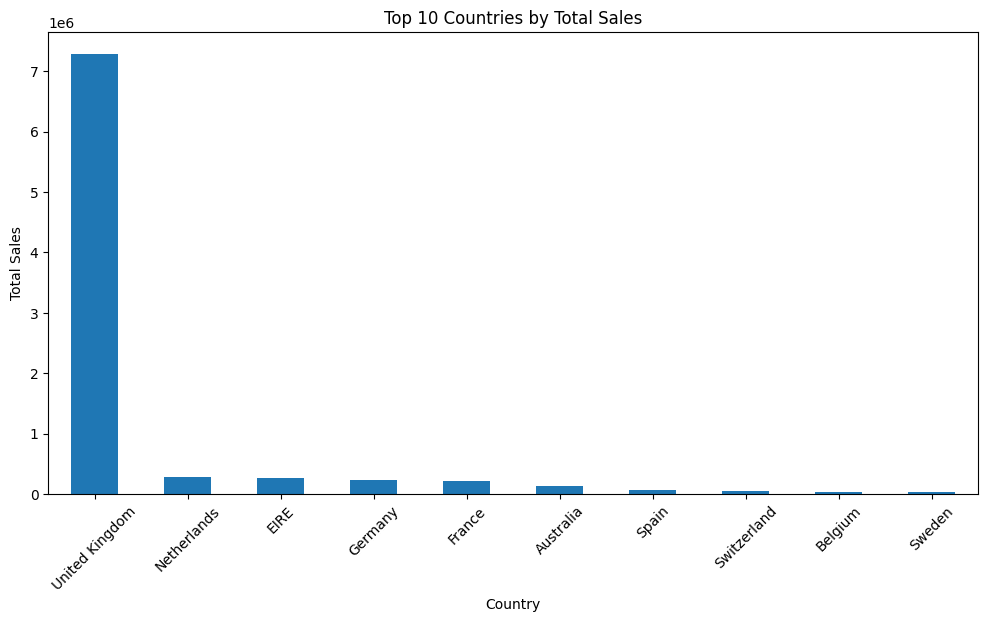

In [ ]:
plt.figure(figsize=(12, 6))

country_sales.head(10).plot(kind='bar')

plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

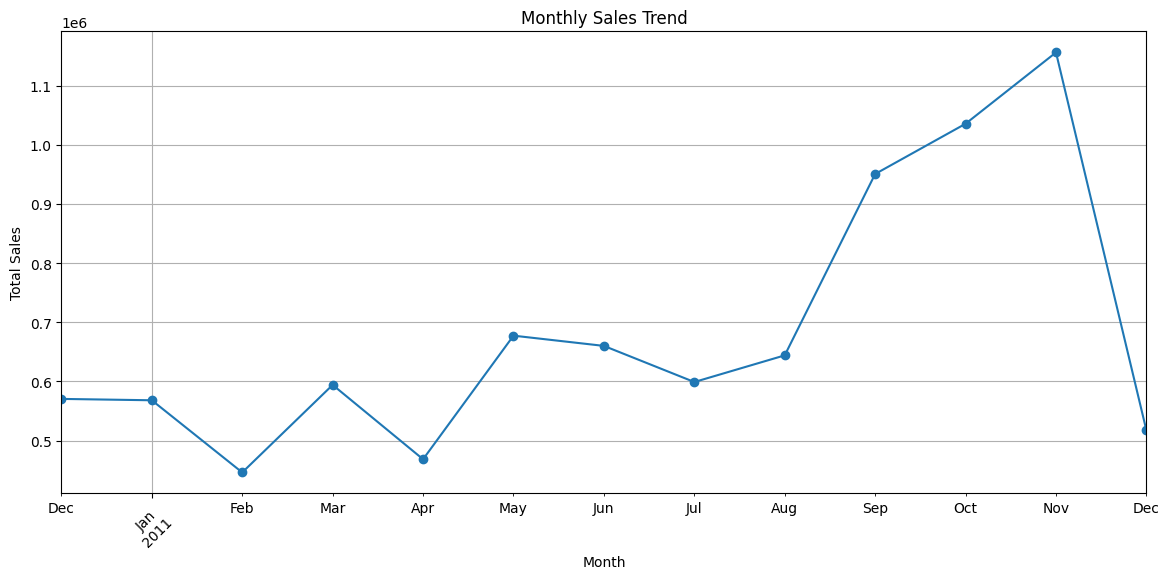

In [ ]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df_clean.groupby('Month')['TotalAmount']
    .sum()
)

plt.figure(figsize=(14, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

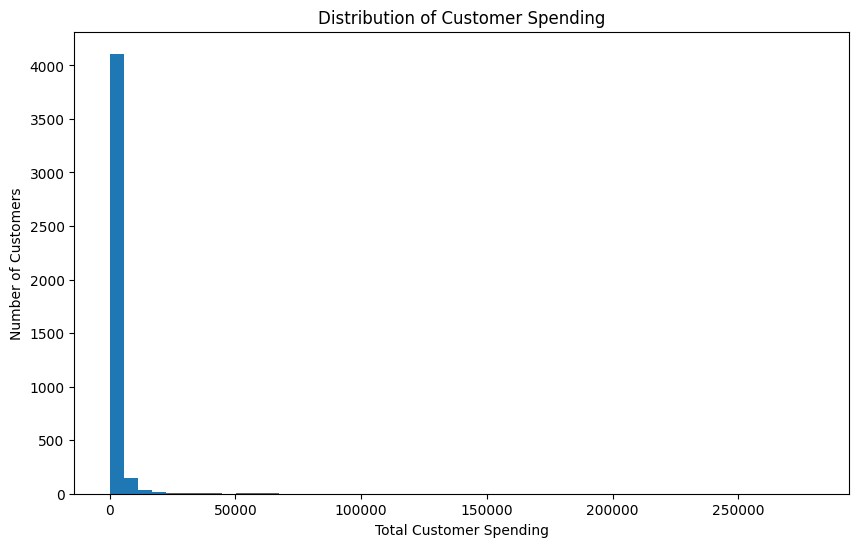

In [ ]:
customer_spending = (
    df_clean.groupby('CustomerID')['TotalAmount']
    .sum()
)

plt.figure(figsize=(10, 6))

plt.hist(customer_spending, bins=50)

plt.title('Distribution of Customer Spending')
plt.xlabel('Total Customer Spending')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
max_date = df_clean['InvoiceDate'].max()

print("Last transaction date:", max_date)

Last transaction date: 2011-12-09 12:50:00


In [ ]:
customer_features = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (max_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    TotalQuantity=('Quantity', 'sum')
).reset_index()

customer_features.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity
0,12346,325,1,77183.60,74215
1,12347,1,7,4310.00,2458
2,12348,74,4,1797.24,2341
3,12349,18,1,1757.55,631
4,12350,309,1,334.40,197


In [ ]:
customer_features['AOV'] = (
    customer_features['Monetary'] /
    customer_features['Frequency']
)

In [ ]:
customer_features[
    ['CustomerID', 'Monetary', 'Frequency', 'AOV']
].head(10)

,CustomerID,Monetary,Frequency,AOV
0,12346,77183.60,1,77183.600000
1,12347,4310.00,7,615.714286
2,12348,1797.24,4,449.310000
3,12349,1757.55,1,1757.550000
4,12350,334.40,1,334.400000
5,12352,2506.04,8,313.255000
6,12353,89.00,1,89.000000
7,12354,1079.40,1,1079.400000
8,12355,459.40,1,459.400000
9,12356,2811.43,3,937.143333


In [ ]:
active_months = (
    df_clean.groupby('CustomerID')['Month']
    .nunique()
    .reset_index(name='ActiveMonths')
)

customer_features = customer_features.merge(
    active_months,
    on='CustomerID',
    how='left'
)

In [ ]:
customer_features['PurchaseFrequency'] = (
    customer_features['Frequency'] /
    customer_features['ActiveMonths']
)

In [ ]:
customer_features.head(10)

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AOV,ActiveMonths,PurchaseFrequency
0,12346,325,1,77183.60,74215,77183.600000,1,1.0
1,12347,1,7,4310.00,2458,615.714286,7,1.0
2,12348,74,4,1797.24,2341,449.310000,4,1.0
3,12349,18,1,1757.55,631,1757.550000,1,1.0
4,12350,309,1,334.40,197,334.400000,1,1.0
5,12352,35,8,2506.04,536,313.255000,4,2.0
6,12353,203,1,89.00,20,89.000000,1,1.0
7,12354,231,1,1079.40,530,1079.400000,1,1.0
8,12355,213,1,459.40,240,459.400000,1,1.0
9,12356,22,3,2811.43,1591,937.143333,3,1.0


In [ ]:
customer_lifetime = (
    df_clean.groupby('CustomerID')['InvoiceDate']
    .agg(['min', 'max'])
    .reset_index()
)

customer_lifetime['LifetimeDays'] = (
    customer_lifetime['max'] -
    customer_lifetime['min']
).dt.days

In [ ]:
customer_features = customer_features.merge(
    customer_lifetime[['CustomerID', 'LifetimeDays']],
    on='CustomerID',
    how='left'
)

In [ ]:
customer_features['LifetimeDays'] = (
    customer_features['LifetimeDays'].replace(0, 1)
)

In [ ]:
customer_features['CLV'] = (
    customer_features['AOV'] *
    customer_features['PurchaseFrequency'] *
    (customer_features['LifetimeDays'] / 30)
)

In [ ]:
customer_features.head(10)

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AOV,ActiveMonths,PurchaseFrequency,LifetimeDays,CLV
0,12346,325,1,77183.60,74215,77183.600000,1,1.0,1,2572.786667
1,12347,1,7,4310.00,2458,615.714286,7,1.0,365,7491.190476
2,12348,74,4,1797.24,2341,449.310000,4,1.0,282,4223.514000
3,12349,18,1,1757.55,631,1757.550000,1,1.0,1,58.585000
4,12350,309,1,334.40,197,334.400000,1,1.0,1,11.146667
5,12352,35,8,2506.04,536,313.255000,4,2.0,260,5429.753333
6,12353,203,1,89.00,20,89.000000,1,1.0,1,2.966667
7,12354,231,1,1079.40,530,1079.400000,1,1.0,1,35.980000
8,12355,213,1,459.40,240,459.400000,1,1.0,1,15.313333
9,12356,22,3,2811.43,1591,937.143333,3,1.0,302,9433.909556


In [ ]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   int64  
 1   Recency            4338 non-null   int64  
 2   Frequency          4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   TotalQuantity      4338 non-null   int64  
 5   AOV                4338 non-null   float64
 6   ActiveMonths       4338 non-null   int64  
 7   PurchaseFrequency  4338 non-null   float64
 8   LifetimeDays       4338 non-null   int64  
 9   CLV                4338 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 339.0 KB


In [ ]:
customer_features.describe()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AOV,ActiveMonths,PurchaseFrequency,LifetimeDays,CLV
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2048.688081,1187.644537,417.645735,3.009221,1.225594,130.807054,2731.197790
std,1721.808492,100.014169,7.697998,8985.230220,5043.619654,1796.511343,2.627853,0.765747,131.685728,12302.054517
min,12346.000000,0.000000,1.000000,3.750000,1.000000,3.450000,1.000000,1.000000,1.000000,0.125000
25%,13813.250000,17.000000,1.000000,306.482500,159.000000,177.867083,1.000000,1.000000,1.000000,12.183667
50%,15299.500000,50.000000,2.000000,668.570000,378.000000,291.940000,2.000000,1.000000,92.500000,837.574361
75%,16778.750000,141.000000,5.000000,1660.597500,989.750000,428.280625,4.000000,1.250000,251.750000,2938.804167
max,18287.000000,373.000000,209.000000,280206.020000,196915.000000,84236.250000,13.000000,34.000000,373.000000,572806.500000


In [ ]:
clustering_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AOV',
    'PurchaseFrequency',
    'CLV'
]

X = customer_features[clustering_features].copy()

print("Features selected:")
print(X.head())

Features selected:
   Recency  Frequency  Monetary           AOV  PurchaseFrequency          CLV
0      325          1  77183.60  77183.600000                1.0  2572.786667
1        1          7   4310.00    615.714286                1.0  7491.190476
2       74          4   1797.24    449.310000                1.0  4223.514000
3       18          1   1757.55   1757.550000                1.0    58.585000
4      309          1    334.40    334.400000                1.0    11.146667


In [ ]:
print("Missing values:")
print(X.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X).sum())

Missing values:
Recency              0
Frequency            0
Monetary             0
AOV                  0
PurchaseFrequency    0
CLV                  0
dtype: int64

Infinite values:
Recency              0
Frequency            0
Monetary             0
AOV                  0
PurchaseFrequency    0
CLV                  0
dtype: int64


In [ ]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Required libraries imported successfully!")

Required libraries imported successfully!


In [ ]:
print(X.shape)

(4338, 6)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=X.index
)

X_scaled.head()

,Recency,Frequency,Monetary,AOV,PurchaseFrequency,CLV
0,2.334574,-0.425097,8.363010,42.735496,-0.294641,-0.012878
1,-0.905340,0.354417,0.251699,0.110264,-0.294641,0.386971
2,-0.175360,-0.035340,-0.027988,0.017627,-0.294641,0.121320
3,-0.735345,-0.425097,-0.032406,0.745923,-0.294641,-0.217274
4,2.174578,-0.425097,-0.190812,-0.046343,-0.294641,-0.221131


In [ ]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

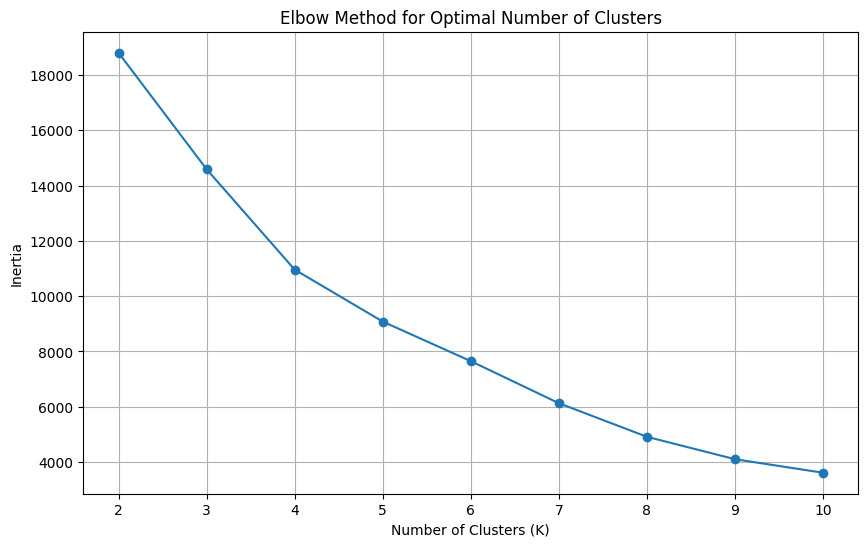

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.grid(True)
plt.show()

In [ ]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.9400
K = 3: Silhouette Score = 0.9091
K = 4: Silhouette Score = 0.5036
K = 5: Silhouette Score = 0.5387
K = 6: Silhouette Score = 0.5389
K = 7: Silhouette Score = 0.5338
K = 8: Silhouette Score = 0.5281
K = 9: Silhouette Score = 0.5251
K = 10: Silhouette Score = 0.3933


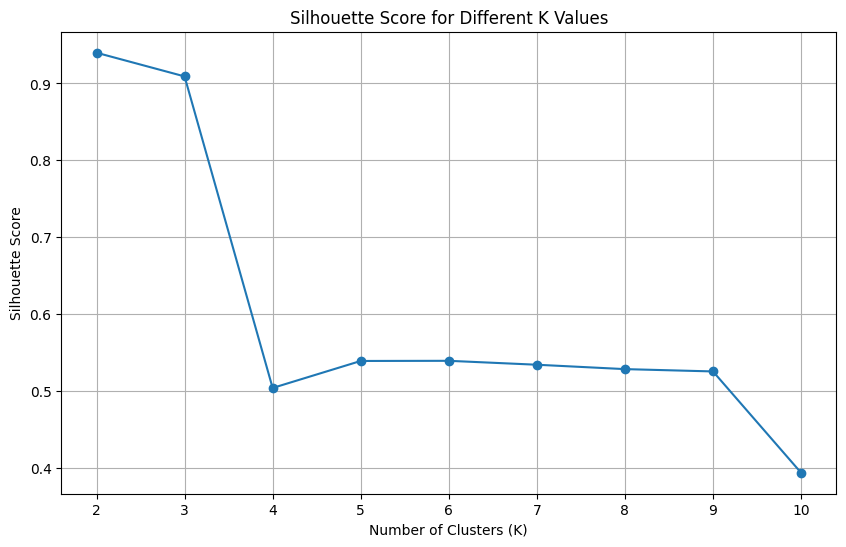

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.grid(True)
plt.show()

In [ ]:
for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.9400
K = 3: Silhouette Score = 0.9091
K = 4: Silhouette Score = 0.5036
K = 5: Silhouette Score = 0.5387
K = 6: Silhouette Score = 0.5389
K = 7: Silhouette Score = 0.5338
K = 8: Silhouette Score = 0.5281
K = 9: Silhouette Score = 0.5251
K = 10: Silhouette Score = 0.3933


In [ ]:
best_k = K_range[np.argmax(silhouette_scores)]

print("Best K based on Silhouette Score:", best_k)

Best K based on Silhouette Score: 2


In [ ]:
best_k = 2

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")

K-Means clustering completed!


In [ ]:
cluster_counts = (
    customer_features['Cluster']
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Cluster
0    4323
1      15
Name: count, dtype: int64


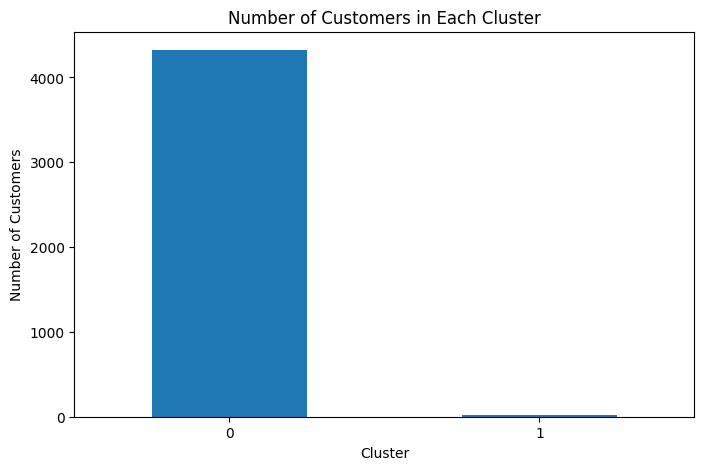

In [ ]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

In [ ]:
cluster_summary = (
    customer_features
    .groupby('Cluster')[
        [
            'Recency',
            'Frequency',
            'Monetary',
            'AOV',
            'PurchaseFrequency',
            'CLV'
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary,AOV,PurchaseFrequency,CLV
Cluster,,,,,,
0,91.67,4.03,1654.22,375.43,1.20,2276.89
1,51.93,73.87,115734.55,12582.84,8.01,133663.24


In [ ]:
cluster_summary

,Recency,Frequency,Monetary,AOV,PurchaseFrequency,CLV
Cluster,,,,,,
0,91.67,4.03,1654.22,375.43,1.20,2276.89
1,51.93,73.87,115734.55,12582.84,8.01,133663.24


In [ ]:
customer_features['Segment'] = customer_features['Cluster'].map({
    0: 'Regular / Lower-Value Customers',
    1: 'High-Value / Loyal Customers'
})

customer_features[['CustomerID', 'Cluster', 'Segment']].head(10)

,CustomerID,Cluster,Segment
0,12346,1,High-Value / Loyal Customers
1,12347,0,Regular / Lower-Value Customers
2,12348,0,Regular / Lower-Value Customers
3,12349,0,Regular / Lower-Value Customers
4,12350,0,Regular / Lower-Value Customers
5,12352,0,Regular / Lower-Value Customers
6,12353,0,Regular / Lower-Value Customers
7,12354,0,Regular / Lower-Value Customers
8,12355,0,Regular / Lower-Value Customers
9,12356,0,Regular / Lower-Value Customers


In [ ]:
print(customer_features['Segment'].value_counts())

Segment
Regular / Lower-Value Customers    4323
High-Value / Loyal Customers         15
Name: count, dtype: int64


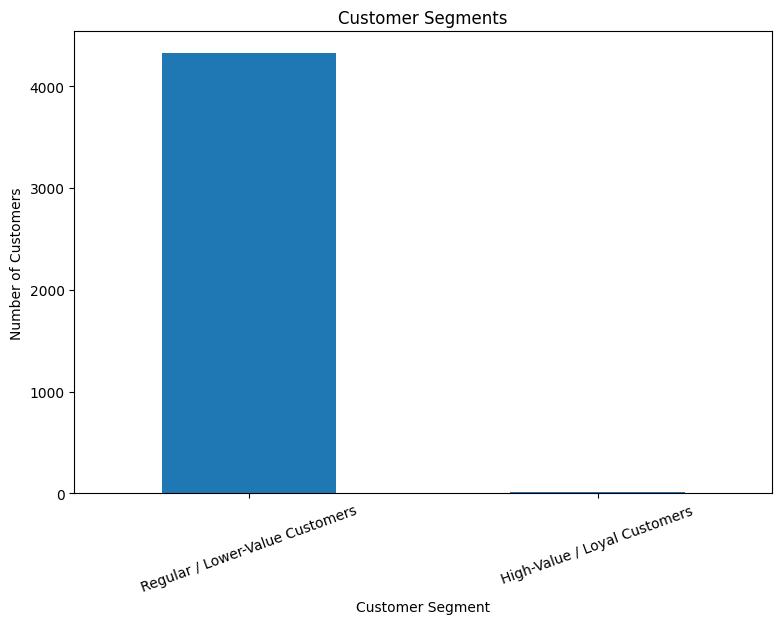

In [ ]:
segment_counts = customer_features['Segment'].value_counts()

plt.figure(figsize=(9, 6))

segment_counts.plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)

plt.show()

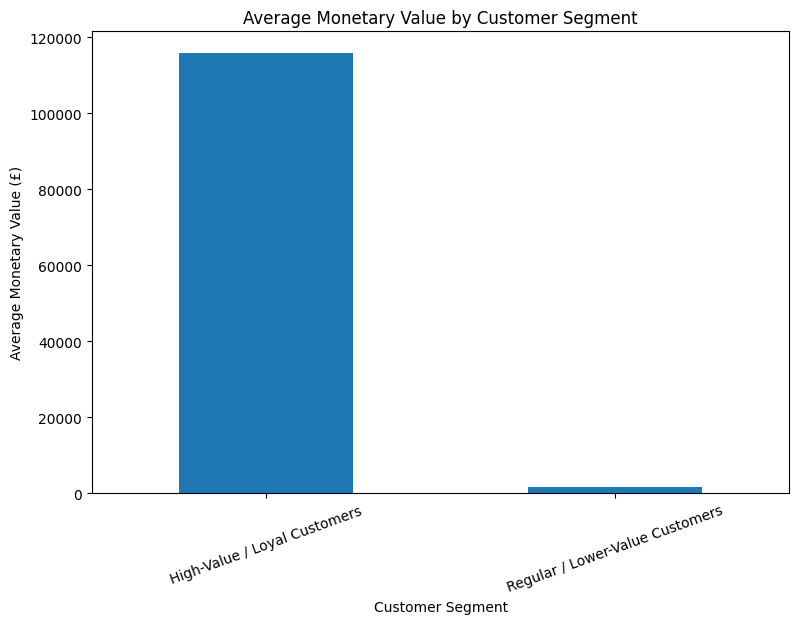

In [ ]:
plt.figure(figsize=(9, 6))

customer_features.groupby('Segment')['Monetary'].mean().plot(kind='bar')

plt.title('Average Monetary Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value (£)')
plt.xticks(rotation=20)

plt.show()

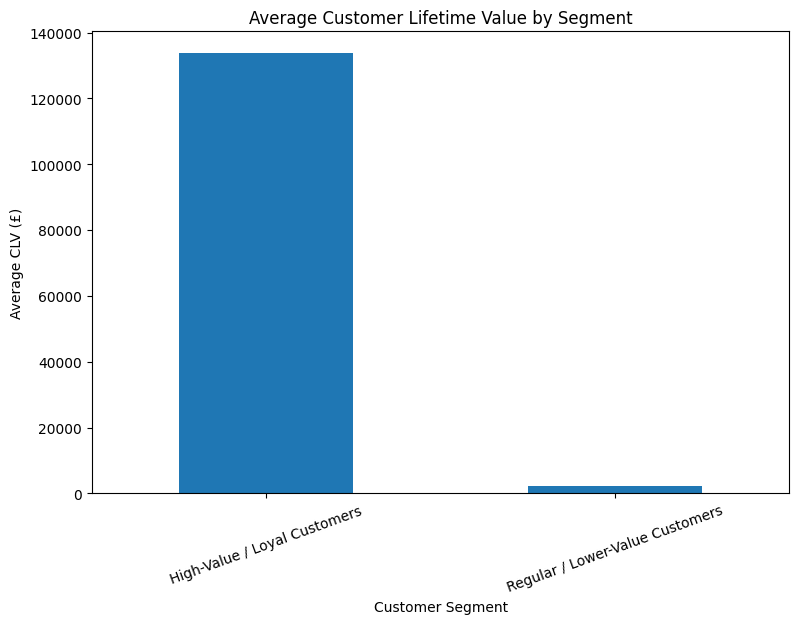

In [ ]:
plt.figure(figsize=(9, 6))

customer_features.groupby('Segment')['CLV'].mean().plot(kind='bar')

plt.title('Average Customer Lifetime Value by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average CLV (£)')
plt.xticks(rotation=20)

plt.show()

In [ ]:
print(customer_features['PurchaseFrequency'].describe())

count    4338.000000
mean        1.225594
std         0.765747
min         1.000000
25%         1.000000
50%         1.000000
75%         1.250000
max        34.000000
Name: PurchaseFrequency, dtype: float64


In [ ]:
purchase_threshold = customer_features['PurchaseFrequency'].median()

print("Purchase frequency threshold:", purchase_threshold)

Purchase frequency threshold: 1.0


In [ ]:
customer_features['LikelyToPurchase'] = (
    customer_features['PurchaseFrequency'] >= purchase_threshold
).astype(int)

In [ ]:
print(customer_features['LikelyToPurchase'].value_counts())

LikelyToPurchase
1    4338
Name: count, dtype: int64


In [ ]:
prediction_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AOV',
    'CLV'
]

X_pred = customer_features[prediction_features]
y_pred = customer_features['LikelyToPurchase']

print("X shape:", X_pred.shape)
print("y shape:", y_pred.shape)

X shape: (4338, 5)
y shape: (4338,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pred,
    y_pred,
    test_size=0.2,
    random_state=42,
    stratify=y_pred
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 3470
Testing records: 868


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_predicted = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_predicted)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       868

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [ ]:
cm = confusion_matrix(y_test, y_predicted)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[868]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


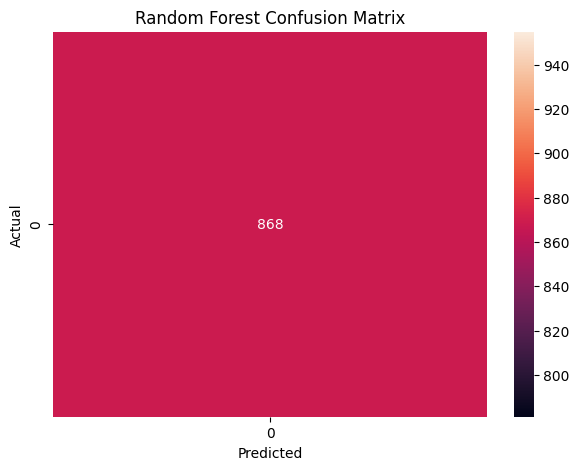

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=prediction_features
).sort_values(ascending=False)

print(feature_importance)

Recency      0.0
Frequency    0.0
Monetary     0.0
AOV          0.0
CLV          0.0
dtype: float64


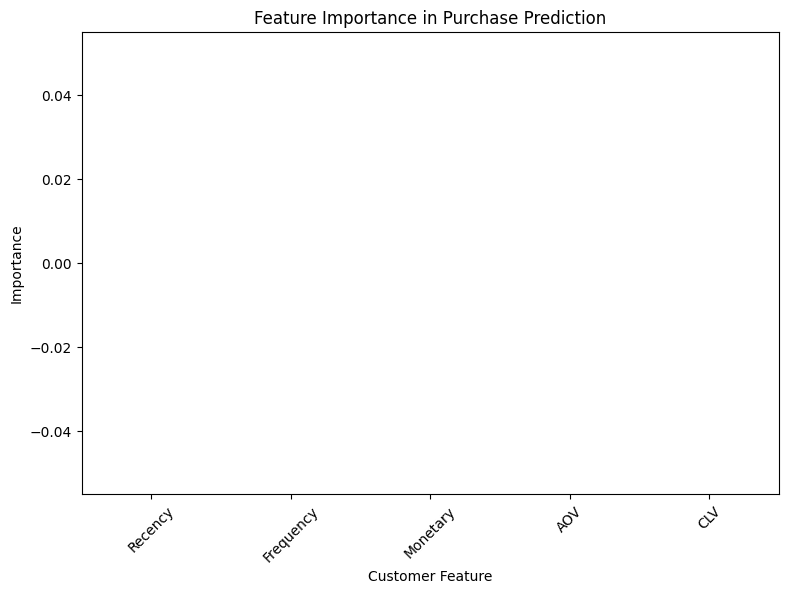

In [ ]:
plt.figure(figsize=(9, 6))

feature_importance.plot(kind='bar')

plt.title('Feature Importance in Purchase Prediction')
plt.xlabel('Customer Feature')
plt.ylabel('Importance')

plt.xticks(rotation=45)

plt.show()

In [ ]:
print("Feature Importance Values:")
print(feature_importance)

print("\nTarget distribution:")
print(y_pred.value_counts())

print("\nRandom Forest classes:")
print(rf_model.classes_)

print("\nModel feature importances:")
print(rf_model.feature_importances_)

Feature Importance Values:
Recency      0.0
Frequency    0.0
Monetary     0.0
AOV          0.0
CLV          0.0
dtype: float64

Target distribution:
LikelyToPurchase
1    4338
Name: count, dtype: int64

Random Forest classes:
[1]

Model feature importances:
[0. 0. 0. 0. 0.]


In [ ]:
print(customer_features[prediction_features].describe())

           Recency    Frequency       Monetary           AOV            CLV
count  4338.000000  4338.000000    4338.000000   4338.000000    4338.000000
mean     91.536422     4.272015    2048.688081    417.645735    2731.197790
std     100.014169     7.697998    8985.230220   1796.511343   12302.054517
min       0.000000     1.000000       3.750000      3.450000       0.125000
25%      17.000000     1.000000     306.482500    177.867083      12.183667
50%      50.000000     2.000000     668.570000    291.940000     837.574361
75%     141.000000     5.000000    1660.597500    428.280625    2938.804167
max     373.000000   209.000000  280206.020000  84236.250000  572806.500000


In [ ]:
print("First transaction:", df_clean['InvoiceDate'].min())
print("Last transaction:", df_clean['InvoiceDate'].max())

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [ ]:
cutoff_date = pd.Timestamp('2011-10-01')

print("Cutoff date:", cutoff_date)

Cutoff date: 2011-10-01 00:00:00


In [ ]:
historical_data = df_clean[
    df_clean['InvoiceDate'] < cutoff_date
].copy()

future_data = df_clean[
    df_clean['InvoiceDate'] >= cutoff_date
].copy()

print("Historical transactions:", len(historical_data))
print("Future transactions:", len(future_data))

Historical transactions: 263705
Future transactions: 128987


In [ ]:
historical_features = historical_data.groupby('CustomerID').agg(
    Recency=('InvoiceDate',
             lambda x: (cutoff_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    TotalQuantity=('Quantity', 'sum')
).reset_index()

In [ ]:
historical_features['AOV'] = (
    historical_features['Monetary'] /
    historical_features['Frequency']
)

In [ ]:
historical_data['Month'] = historical_data['InvoiceDate'].dt.to_period('M')

historical_months = (
    historical_data.groupby('CustomerID')['Month']
    .nunique()
    .reset_index(name='ActiveMonths')
)

historical_features = historical_features.merge(
    historical_months,
    on='CustomerID',
    how='left'
)

In [ ]:
historical_features['PurchaseFrequency'] = (
    historical_features['Frequency'] /
    historical_features['ActiveMonths']
)

In [ ]:
future_purchases = (
    future_data.groupby('CustomerID')
    .size()
    .reset_index(name='FuturePurchases')
)

In [ ]:
prediction_data = historical_features.merge(
    future_purchases,
    on='CustomerID',
    how='left'
)

In [ ]:
prediction_data['FuturePurchases'] = (
    prediction_data['FuturePurchases'].fillna(0)
)

In [ ]:
prediction_data['LikelyToPurchase'] = (
    prediction_data['FuturePurchases'] > 0
).astype(int)

In [ ]:
print(
    prediction_data['LikelyToPurchase'].value_counts()
)

LikelyToPurchase
1    1838
0    1778
Name: count, dtype: int64


In [ ]:
print(
    prediction_data['LikelyToPurchase']
    .value_counts(normalize=True)
)

LikelyToPurchase
1    0.508296
0    0.491704
Name: proportion, dtype: float64


In [ ]:
prediction_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AOV',
    'PurchaseFrequency'
]

X_pred = prediction_data[prediction_features]
y_pred = prediction_data['LikelyToPurchase']

print("X shape:", X_pred.shape)
print("y shape:", y_pred.shape)

X shape: (3616, 5)
y shape: (3616,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pred,
    y_pred,
    test_size=0.2,
    random_state=42,
    stratify=y_pred
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 2892
Testing records: 724


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
y_predicted = rf_model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_predicted)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 63.26 %


In [ ]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.62      0.64      0.63       356
           1       0.64      0.62      0.63       368

    accuracy                           0.63       724
   macro avg       0.63      0.63      0.63       724
weighted avg       0.63      0.63      0.63       724



In [ ]:
cm = confusion_matrix(y_test, y_predicted)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[228 128]
 [138 230]]


In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=prediction_features
).sort_values(ascending=False)

print(feature_importance)

Monetary             0.311702
Recency              0.271408
AOV                  0.270161
Frequency            0.109835
PurchaseFrequency    0.036894
dtype: float64


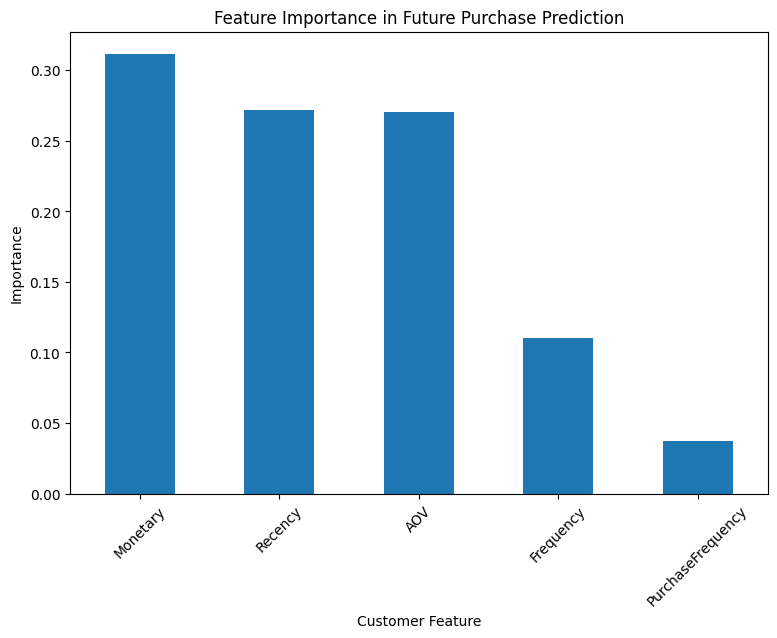

In [ ]:
plt.figure(figsize=(9, 6))

feature_importance.plot(kind='bar')

plt.title('Feature Importance in Future Purchase Prediction')
plt.xlabel('Customer Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.show()

In [ ]:
print("===== MODEL RESULTS =====")

print("\nAccuracy:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_predicted))

print("\nConfusion Matrix:")
print(cm)

print("\nFeature Importance:")
print(feature_importance)

===== MODEL RESULTS =====

Accuracy:
63.26 %

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       356
           1       0.64      0.62      0.63       368

    accuracy                           0.63       724
   macro avg       0.63      0.63      0.63       724
weighted avg       0.63      0.63      0.63       724


Confusion Matrix:
[[228 128]
 [138 230]]

Feature Importance:
Monetary             0.311702
Recency              0.271408
AOV                  0.270161
Frequency            0.109835
PurchaseFrequency    0.036894
dtype: float64


In [ ]:
print("===== SEGMENT SUMMARY =====")
print(cluster_summary)

print("\n===== SEGMENT COUNTS =====")
print(customer_features['Segment'].value_counts())

===== SEGMENT SUMMARY =====
         Recency  Frequency   Monetary       AOV  PurchaseFrequency        CLV
Cluster                                                                       
0          91.67       4.03    1654.22    375.43               1.20    2276.89
1          51.93      73.87  115734.55  12582.84               8.01  133663.24

===== SEGMENT COUNTS =====
Segment
Regular / Lower-Value Customers    4323
High-Value / Loyal Customers         15
Name: count, dtype: int64


Business Insights

1. Customer Segmentation
- 4,323 customers are Regular / Lower-Value Customers.
- 15 customers are High-Value / Loyal Customers.
- High-value customers have substantially higher spending, frequency, AOV, and CLV.

2. Purchase Prediction
- Random Forest achieved 63.26% accuracy.
- Precision, recall, and F1-score were approximately 0.63.
- The model provides moderate predictive performance.

3. Important Predictors
- Monetary value is the most important predictor (31.17%).
- Recency is the second most important (27.14%).
- AOV is the third most important (27.02%).
- Frequency contributes 10.98%.
- Purchase Frequency contributes 3.69%.

4. Marketing Recommendations
- High-value customers: VIP programs, personalized offers, exclusive products, and retention campaigns.
- Regular customers: discounts, re-engagement campaigns, cross-selling, and personalized recommendations.

Conclusion:
This project analyzed customer purchasing behavior using Python-based data analytics and machine learning techniques. The dataset was cleaned and transformed into customer-level features including Recency, Frequency, Monetary value, Average Order Value, Purchase Frequency, and Customer Lifetime Value. K-Means clustering identified two customer segments: Regular/Lower-Value Customers and High-Value/Loyal Customers. The segmentation revealed that a small group of highly valuable customers contributes substantially greater purchasing value. A Random Forest classification model was then developed to predict future purchase behavior and achieved an accuracy of 63.26%. Monetary value, Recency, and Average Order Value were identified as the most influential predictive features. These findings can help businesses develop targeted retention, personalization, and customer engagement strategies.